### 데이터 로드하기 [ preprocess] 거침

### inceptionv3 모듈 불러오기 ( NO Weight)

##

kernel 수 계산공식     : 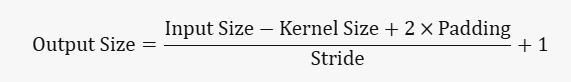

## 1. GPU

In [1]:
import os
import tensorflow as tf 
from tensorflow.python.client import device_lib

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [ ]:
print(device_lib.list_local_devices())

In [ ]:
from ultralytics import YOLO

# Load a model
model = YOLO("yolo11n-pose.yaml")  # build a new model from YAML
model = YOLO("yolo11n-pose.pt")  # load a pretrained model (recommended for training)
model = YOLO("yolo11n-pose.yaml").load("yolo11n-pose.pt")  # build from YAML and transfer weights

# Train the model
results = model.train(data="coco8-pose.yaml", epochs=100, imgsz=640)

In [8]:
from ultralytics import YOLO
import torch
import os

# 모델 로드
model_path = "yolo11n-pose.pt"
if not os.path.exists(model_path):
    raise FileNotFoundError(f"모델 파일이 존재하지 않습니다: {model_path}")

model = YOLO(model_path)

# 데이터셋 설정 파일 확인
data_yaml = "hongyolo.yaml"
if not os.path.exists(data_yaml):
    raise FileNotFoundError(f"데이터 설정 파일이 존재하지 않습니다: {data_yaml}")

# 훈련 실행
result = None  # 변수 초기화
try:
    result = model.train(
        data=data_yaml,
        epochs=50,
        imgsz=640,
        batch=16,
        device='cpu'  # GPU 사용 시 'cuda'로 변경
    )
    print("훈련 완료!")
except Exception as e:
    print(f"훈련 중 오류 발생: {e}")
    exit(1)  # 오류 발생 시 종료

# 훈련 성공 시 결과 출력
if result is not None:
    print("훈련 결과 요약: ")
    print(result)

    # 검증 실행
    try:
        val_results = model.val()
        print("\nValidation 결과:")
        print(f"Precision: {val_results.metrics['precision']:.4f}")
        print(f"Recall: {val_results.metrics['recall']:.4f}")
        print(f"mAP@0.5: {val_results.metrics['map50']:.4f}")
        print(f"mAP@0.5:0.95: {val_results.metrics['map']:.4f}")
    except Exception as e:
        print(f"검증 중 오류 발생: {e}")
else:
    print("훈련이 실패하여 검증을 수행
          하지 않습니다.")

FileNotFoundError: 데이터 설정 파일이 존재하지 않습니다: hongyolo.yaml

## 2. Inception function


In [ ]:
import os
import tensorflow as tf 
from tensorflow.python.client import device_lib
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras import callbacks
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import tensorflow as tf
from tensorflow.keras.layers import Conv2D, ZeroPadding2D, BatchNormalization, ReLU, AveragePooling2D, Dense, Dropout, Flatten, MaxPooling2D, concatenate, GlobalAveragePooling2D, Input, Activation
from tensorflow.keras import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model
import matplotlib.pyplot as plt
import numpy as np
import os
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True


os.environ["CUDA_VISIBLE_DEVICES"] = "0"
print(device_lib.list_local_devices())
print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))


def preprocess_image(image):
    if image.shape[-1] == 1:
        image = tf.image.grayscale_to_rgb(image)
    return image

batch_size = 16
train_dir = 'F:/BR/dataset/Train data'
test_dir = 'F:/BR/dataset/Test data'

train_data_pre = ImageDataGenerator(preprocessing_function=preprocess_image)
test_data_pre = ImageDataGenerator(preprocessing_function=preprocess_image)

train_data = train_data_pre.flow_from_directory(
    train_dir,
    target_size=(299, 299),
    batch_size=batch_size,
    class_mode='categorical'
)

test_data = test_data_pre.flow_from_directory(
    test_dir,
    target_size=(299, 299),
    batch_size=batch_size,
    class_mode='categorical'
)

def InceptionV3():
    input_layer = Input(shape=(299 , 299 , 3))
    
    x = StemBlock(input_layer)
    
    x = InceptionBlock_A(prev_layer=x, nbr_kernels=32)
    x = InceptionBlock_A(prev_layer=x, nbr_kernels=64)
    x = InceptionBlock_A(prev_layer=x, nbr_kernels=64)
    
    x = ReductionBlock_A(prev_layer=x)
    
    x = InceptionBlock_B(prev_layer=x, nbr_kernels=128)
    x = InceptionBlock_B(prev_layer=x, nbr_kernels=160)
    x = InceptionBlock_B(prev_layer=x, nbr_kernels=160)
    x = InceptionBlock_B(prev_layer=x, nbr_kernels=192)
    
    Aux = auxiliary_classifier(prev_Layer=x)
    
    x = ReductionBlock_B(prev_layer=x)
    
    x = InceptionBlock_C(prev_layer=x)
    x = InceptionBlock_C(prev_layer=x)
    
    x = GlobalAveragePooling2D()(x)
    x = Dense(units=2048, activation='relu')(x)
    x = Dropout(rate=0.2)(x)
    
    # 고유한 이름을 사용하도록 변경
    x_output = Dense(units=5, activation='softmax', name='main_output')(x)  # 주 출력의 이름 변경
    Aux_output = Dense(units=5, activation='softmax', name='auxiliary_output')(Aux)  # 보조 출력의 이름 변경

    # 모델 정의
    model = Model(inputs=input_layer, outputs=[x_output, Aux_output], name='Inception-V3')
    
    return model


def conv_with_Batch_Normalisation(prev_layer , nbr_kernels , filter_Size , strides =(1,1) , padding = 'same'):
    x = Conv2D(filters=nbr_kernels, kernel_size = filter_Size, strides=strides , padding=padding)(prev_layer)
    x = BatchNormalization(axis=3)(x)
    x = Activation(activation='relu')(x)
    return x


def StemBlock(prev_layer):
    x = conv_with_Batch_Normalisation(prev_layer, nbr_kernels = 32, filter_Size=(3,3) , strides=(2,2))
    x = conv_with_Batch_Normalisation(x, nbr_kernels = 32, filter_Size=(3,3))
    x = conv_with_Batch_Normalisation(x, nbr_kernels = 64, filter_Size=(3,3))
    x = MaxPooling2D(pool_size=(3,3) , strides=(2,2)) (x)
    x = conv_with_Batch_Normalisation(x, nbr_kernels = 80, filter_Size=(1,1))
    x = conv_with_Batch_Normalisation(x, nbr_kernels = 192, filter_Size=(3,3))
    x = MaxPooling2D(pool_size=(3,3) , strides=(2,2)) (x)
    return x    
    

def InceptionBlock_A(prev_layer , nbr_kernels):
    
    branch1 = conv_with_Batch_Normalisation(prev_layer, nbr_kernels = 64, filter_Size = (1,1))
    branch1 = conv_with_Batch_Normalisation(branch1, nbr_kernels=96, filter_Size=(3,3))
    branch1 = conv_with_Batch_Normalisation(branch1, nbr_kernels=96, filter_Size=(3,3))
    
    branch2 = conv_with_Batch_Normalisation(prev_layer, nbr_kernels=48, filter_Size=(1,1))
    branch2 = conv_with_Batch_Normalisation(branch2, nbr_kernels=64, filter_Size=(3,3)) # may be 3*3
    
    branch3 = AveragePooling2D(pool_size=(3,3) , strides=(1,1) , padding='same') (prev_layer)
    branch3 = conv_with_Batch_Normalisation(branch3, nbr_kernels = nbr_kernels, filter_Size = (1,1))
    
    branch4 = conv_with_Batch_Normalisation(prev_layer, nbr_kernels=64, filter_Size=(1,1))
    
    output = concatenate([branch1 , branch2 , branch3 , branch4], axis=3)
    
    return output


def InceptionBlock_B(prev_layer , nbr_kernels):
    
    branch1 = conv_with_Batch_Normalisation(prev_layer, nbr_kernels = nbr_kernels, filter_Size = (1,1))
    branch1 = conv_with_Batch_Normalisation(branch1, nbr_kernels = nbr_kernels, filter_Size = (7,1))
    branch1 = conv_with_Batch_Normalisation(branch1, nbr_kernels = nbr_kernels, filter_Size = (1,7))
    branch1 = conv_with_Batch_Normalisation(branch1, nbr_kernels = nbr_kernels, filter_Size = (7,1))    
    branch1 = conv_with_Batch_Normalisation(branch1, nbr_kernels = 192, filter_Size = (1,7))
    
    branch2 = conv_with_Batch_Normalisation(prev_layer, nbr_kernels = nbr_kernels, filter_Size = (1,1))
    branch2 = conv_with_Batch_Normalisation(branch2, nbr_kernels = nbr_kernels, filter_Size = (1,7))
    branch2 = conv_with_Batch_Normalisation(branch2, nbr_kernels = 192, filter_Size = (7,1))
    
    branch3 = AveragePooling2D(pool_size=(3,3) , strides=(1,1) , padding ='same') (prev_layer)
    branch3 = conv_with_Batch_Normalisation(branch3, nbr_kernels = 192, filter_Size = (1,1))
    
    branch4 = conv_with_Batch_Normalisation(prev_layer, nbr_kernels = 192, filter_Size = (1,1))
    
    output = concatenate([branch1 , branch2 , branch3 , branch4], axis = 3)
    
    return output    

    
def InceptionBlock_C(prev_layer):
    
    branch1 = conv_with_Batch_Normalisation(prev_layer, nbr_kernels = 448, filter_Size = (1,1))
    branch1 = conv_with_Batch_Normalisation(branch1, nbr_kernels = 384, filter_Size = (3,3))
    branch1_1 = conv_with_Batch_Normalisation(branch1, nbr_kernels = 384, filter_Size = (1,3))    
    branch1_2 = conv_with_Batch_Normalisation(branch1, nbr_kernels = 384, filter_Size = (3,1))
    branch1 = concatenate([branch1_1 , branch1_2], axis = 3)
    
    branch2 = conv_with_Batch_Normalisation(prev_layer, nbr_kernels = 384, filter_Size = (1,1))
    branch2_1 = conv_with_Batch_Normalisation(branch2, nbr_kernels = 384, filter_Size = (1,3))
    branch2_2 = conv_with_Batch_Normalisation(branch2, nbr_kernels = 384, filter_Size = (3,1))
    branch2 = concatenate([branch2_1 , branch2_2], axis = 3)
    
    branch3 = AveragePooling2D(pool_size=(3,3) , strides=(1,1) , padding='same')(prev_layer)
    branch3 = conv_with_Batch_Normalisation(branch3, nbr_kernels = 192, filter_Size = (1,1))
    
    branch4 = conv_with_Batch_Normalisation(prev_layer, nbr_kernels = 320, filter_Size = (1,1))
    
    output = concatenate([branch1 , branch2 , branch3 , branch4], axis = 3)
    
    return output


def ReductionBlock_A(prev_layer):
    
    branch1 = conv_with_Batch_Normalisation(prev_layer, nbr_kernels = 64, filter_Size = (1,1))
    branch1 = conv_with_Batch_Normalisation(branch1, nbr_kernels = 96, filter_Size = (3,3))
    branch1 = conv_with_Batch_Normalisation(branch1, nbr_kernels = 96, filter_Size = (3,3) , strides=(2,2) ) #, padding='valid'
    
    branch2 = conv_with_Batch_Normalisation(prev_layer, nbr_kernels = 384, filter_Size=(3,3) , strides=(2,2) )
    
    branch3 = MaxPooling2D(pool_size=(3,3) , strides=(2,2) , padding='same')(prev_layer)
    
    output = concatenate([branch1 , branch2 , branch3], axis = 3)
    
    return output


def ReductionBlock_B(prev_layer):
    
    branch1 = conv_with_Batch_Normalisation(prev_layer, nbr_kernels = 192, filter_Size = (1,1))
    branch1 = conv_with_Batch_Normalisation(branch1, nbr_kernels = 192, filter_Size = (1,7))
    branch1 = conv_with_Batch_Normalisation(branch1, nbr_kernels = 192, filter_Size = (7,1))
    branch1 = conv_with_Batch_Normalisation(branch1, nbr_kernels = 192, filter_Size = (3,3) , strides=(2,2) , padding = 'valid')
    
    branch2 = conv_with_Batch_Normalisation(prev_layer, nbr_kernels = 192, filter_Size = (1,1) )
    branch2 = conv_with_Batch_Normalisation(branch2, nbr_kernels = 320, filter_Size = (3,3) , strides=(2,2) , padding='valid' )

    branch3 = MaxPooling2D(pool_size=(3,3) , strides=(2,2) )(prev_layer)
    
    output = concatenate([branch1 , branch2 , branch3], axis = 3)
    
    return output


def auxiliary_classifier(prev_Layer):
    x = AveragePooling2D(pool_size=(5,5) , strides=(3,3)) (prev_Layer)
    x = conv_with_Batch_Normalisation(x, nbr_kernels = 128, filter_Size = (1,1))
    x = Flatten()(x)
    x = Dense(units = 768, activation='relu') (x)
    x = Dropout(rate = 0.2) (x)
    x = Dense(units = 5, activation='softmax') (x)
 
    return x
7
# Building the Incpetion V3 Model Architecture

model = InceptionV3()

chkpt = ModelCheckpoint(filepath='weights/inceptionv3_model_weights', save_best_only=True, save_weights_only=False, save_format='tf')

model.compile(
    optimizer=Adam(),
    loss={'main_output': CategoricalCrossentropy(label_smoothing=0.1), 'auxiliary_output': CategoricalCrossentropy(label_smoothing=0.1)},
    metrics={'main_output': 'accuracy', 'auxiliary_output': 'accuracy'}
)


# 모델 요약
model.summary()
plot_model(model, to_file="my_model.png", show_shapes=True)

# 모델 학습
history = model.fit(
    train_data,
    epochs=100,
    validation_data=test_data,
    callbacks=[chkpt]
)
# 모델 평가
model.evaluate(test_data)

# 모델 평가 후 정확한 키 이름으로 접근합니다.
print(history.history.keys())

# 학습 정확도와 검증 정확도 가져오기
acc = history.history.get('main_output_accuracy')
val_acc = history.history.get('val_main_output_accuracy')

# 학습 손실과 검증 손실 가져오기
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

# 정확도 시각화
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.legend()

plt.figure()

# 손실 시각화
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.legend()
plt.show()
plt.show()



## 저장된 가중치로 예측하기 

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
import os
import glob
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.inception_v3 import preprocess_input
from PIL import Image
import matplotlib.pyplot as plt


# 모델 로드
model = load_model('weights/inceptionv3_model_weights')

# 모델 컴파일
model.compile(
    optimizer='adam',
    loss={'main_output': 'categorical_crossentropy', 'auxiliary_output': 'categorical_crossentropy'},
    metrics={'main_output': 'accuracy', 'auxiliary_output': 'accuracy'}
)

class_names = ['Heart', 'Oblong', 'Oval', 'Round', 'Square']

# 훈련 시 사용한 전처리 함수
def preprocess_image(image):
    if image.shape[-1] == 1:  # 그레이스케일 이미지 확인
        image = tf.image.grayscale_to_rgb(image)  # 그레이스케일 -> RGB 변환
    return image

def preprocess_and_predict(image_path):
    # 새 이미지 불러오기 및 전처리
    img = image.load_img(image_path, target_size=(299, 299))  # 모델에 맞는 크기로 조정
    img_array = image.img_to_array(img)
    img_array = preprocess_image(img_array)  # 훈련 시 사용한 전처리 함수 적용
    img_array = preprocess_input(img_array)  # InceptionV3의 전처리 함수 사용
    img_array = np.expand_dims(img_array, axis=0)  # 배치 차원 추가

    # 예측 실행
    predictions = model.predict(img_array)
    print(predictions)
    main_output = predictions[0]  # 주 출력(main_output) 사용 (리스트 형식일 때)

    # 클래스 예측 및 확률 추출
    predicted_class = np.argmax(main_output, axis=1)[0]
    confidence = np.max(main_output, axis=1)[0] * 100  # 확률 백분율로 변환
    class_label = class_names[predicted_class]
    
    return class_label, confidence


def load_latest_photo(directory):
    files = glob.glob(os.path.join(directory, '*.jpg'))  # 또는 '*.png'로 변경 가능
    if not files:
        return None
    latest_file = max(files, key=os.path.getctime)
    return latest_file


latest_photo = load_latest_photo("F:\\BR\\user_image")
if latest_photo:
    # 예측 결과 출력
    face_shape, confidence = preprocess_and_predict(latest_photo)
    print(f"The predicted face shape is '{face_shape}' with a confidence of {confidence:.2f}%.")
else:
    print("No photos found in the directory.")
    
printimage = Image.open(latest_photo)
plt.imshow(printimage)
plt.axis('off')
plt.show()


## Mediapipe Land mark 좌표 잡기

In [ ]:
import cv2
import mediapipe as mp

# Mediapipe 초기화
mp_face_mesh = mp.solutions.face_mesh
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles

# 이미지 파일 경로
image_path = "F:\\BR\\user_image\\face_picture.jpg"


# Mediapipe FaceMesh 모델 초기화
face_mesh = mp_face_mesh.FaceMesh(static_image_mode=True, max_num_faces=1, min_detection_confidence=0.5)

# 이미지 불러오기
image = cv2.imread(image_path)
if image is None:
    print("이미지를 불러올 수 없습니다.")
    exit()

# RGB로 변환 (Mediapipe는 RGB 이미지 사용)
rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Mediapipe로 얼굴 랜드마크 추출
results = face_mesh.process(rgb_image)

# 얼굴 랜드마크 번호와 좌표 출력
if results.multi_face_landmarks:
    for face_landmarks in results.multi_face_landmarks:
        print("얼굴 랜드마크 좌표:")
        for idx, landmark in enumerate(face_landmarks.landmark):
            x = int(landmark.x * image.shape[1])  # x 좌표 (이미지 크기 반영)
            y = int(landmark.y * image.shape[0])  # y 좌표 (이미지 크기 반영)
            print(f"번호: {idx}, 좌표: ( {x}, {y})")

            # 랜드마크 번호를 이미지에 표시
            cv2.putText(image, str(idx), (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.3, (0, 255, 0), 1)

# 이미지 출력
cv2.imshow("Face Landmarks", image)
cv2.waitKey(0)
cv2.destroyAllWindows()

# Mediapipe 리소스 해제
face_mesh.close()


## Guide Line 지정위치에 hair overlay

In [ ]:
import cv2
# 예제용 얼굴 감지 및 가이드라인 코드
frame = cv2.imread('face_picture.jpg')  # 예제 프레임 로드
frame = cv2.resize(frame, (1280, 720))
print(frame)

In [ ]:
import cv2

# 예제용 얼굴 감지 및 가이드라인 코드
frame = cv2.imread('face_picture.jpg')  # 예제 프레임 로드
frame = cv2.resize(frame, (1280, 720))
original_frame = frame.copy()

# 얼굴 감지
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
# 예시용으로 비어있는 Haar Cascade 객체
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')
faces = face_cascade.detectMultiScale(gray, 1.3, 5)

# 가이드라인 그리기
guide_color = (0, 255, 0)  # 녹색 가이드라인
guide_thickness = 2

guide_w = 660
guide_h = 550
guide_x = (1280 - guide_w) // 2
guide_y = (720 - guide_h) // 2

cv2.rectangle(frame, (guide_x, guide_y), (guide_x + guide_w, guide_y + guide_h), guide_color, guide_thickness)

# 중앙 상부쪽에 이미지를 삽입
overlay_image = cv2.imread("F:/BR/hair_reco/man/Heart/square-3.png")
 # 삽입할 이미지 로드
overlay_image = cv2.resize(overlay_image, (300, 300))  # 300x300 크기로 조정

# 삽입할 위치 계산
overlay_x = guide_x + (guide_w - 300) // 2  # 가이드라인 중앙에 맞춤
overlay_y = guide_y - 300  # 중앙 상부쪽

# 이미지 삽입 (ROI 지정 후 병합)
if 0 <= overlay_x < 1280 and 0 <= overlay_y < 720:
    try:
        frame[overlay_y:overlay_y + 300, overlay_x:overlay_x + 300] = overlay_image
    except:
        print("삽입할 위치가 프레임 범위를 벗어났습니다.")

# 결과 출력
cv2.imshow('Frame with Overlay', frame)
cv2.waitKey(0)
cv2.destroyAllWindows()


## PYQR Final 코드

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
import os
import glob
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow import keras
import cv2
from PyQt5 import QtCore, QtGui, QtWidgets
from PyQt5.QtGui import QImage, QPixmap
from PyQt5.QtWidgets import QApplication 
import random
import mediapipe as mp
from datetime import datetime


class Ui_MainWindow(object):
    def setupUi(self, MainWindow):
        MainWindow.setObjectName("MainWindow")
        MainWindow.resize(2560, 1440)

        self.centralwidget = QtWidgets.QWidget(MainWindow)
        self.centralwidget.setObjectName("centralwidget")

        self.original_pic = QtWidgets.QLabel(self.centralwidget)
        self.original_pic.setGeometry(QtCore.QRect(70, 90, 911, 800))
        self.original_pic.setObjectName("original_pic")

        self.overlay_pic = QtWidgets.QLabel(self.centralwidget)
        self.overlay_pic.setGeometry(QtCore.QRect(1450, 90, 911, 800))
        self.overlay_pic.setObjectName("overlay_pic")
       
        self.take_pic = QtWidgets.QPushButton(self.centralwidget)
        self.take_pic.setGeometry(QtCore.QRect(70, 950, 531, 131))
        self.take_pic.setObjectName("take_pic")

        self.face_shape = QtWidgets.QPushButton(self.centralwidget)
        self.face_shape.setGeometry(QtCore.QRect(70, 1110, 531, 261))
        self.face_shape.setObjectName("face_shape")

        self.man = QtWidgets.QPushButton(self.centralwidget)
        self.man.setGeometry(QtCore.QRect(1420, 920, 451, 81))
        self.man.setObjectName("man")

        self.women = QtWidgets.QPushButton(self.centralwidget)
        self.women.setGeometry(QtCore.QRect(1910, 920, 451, 81))
        self.women.setObjectName("women")

        self.recommend = QtWidgets.QPushButton(self.centralwidget)
        self.recommend.setGeometry(QtCore.QRect(1420, 1010, 941, 151))
        self.recommend.setObjectName("recommend")

        self.re_recommend = QtWidgets.QPushButton(self.centralwidget)
        self.re_recommend.setGeometry(QtCore.QRect(1420, 1180, 291, 191))
        self.re_recommend.setObjectName("re_recommend")

        self.save = QtWidgets.QPushButton(self.centralwidget)
        self.save.setGeometry(QtCore.QRect(1740, 1180, 271, 191))
        self.save.setObjectName("save")

        self.outout = QtWidgets.QPushButton(self.centralwidget)
        self.outout.setGeometry(QtCore.QRect(2040, 1180, 321, 191))
        self.outout.setObjectName("outout")

        self.face_shape_result = QtWidgets.QLabel(self.centralwidget)
        self.face_shape_result.setGeometry(QtCore.QRect(670, 1100, 421, 261))
        self.face_shape_result.setObjectName("face_shape_result")

        MainWindow.setCentralWidget(self.centralwidget)
        self.menubar = QtWidgets.QMenuBar(MainWindow)
        self.menubar.setGeometry(QtCore.QRect(0, 0, 2560, 22))
        self.menubar.setObjectName("menubar")

        MainWindow.setMenuBar(self.menubar)
        self.statusbar = QtWidgets.QStatusBar(MainWindow)
        self.statusbar.setObjectName("statusbar")

        MainWindow.setStatusBar(self.statusbar)

        self.retranslateUi(MainWindow)
        QtCore.QMetaObject.connectSlotsByName(MainWindow)

#ㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡ#
        self.man.clicked.connect(self.man_chose)
        self.women.clicked.connect(self.women_chose)
        self.take_pic.clicked.connect(self.capture_pic)
        self.face_shape.clicked.connect(self.face)
        self.recommend.clicked.connect(self.reco)
        self.save.clicked.connect(self.savesave)
        self.outout.clicked.connect(self.outoutout)
        self.re_recommend.clicked.connect(self.rereco)


#ㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡ#
# 사진 촬영 (Guide Line) 

    def capture_pic(self):
            cap = cv2.VideoCapture(0)
            if not cap.isOpened():
                print("카메라를 열 수 없습니다.")
                return

            print("사진을 찍으려면 'c' 키를 누르세요. 종료하려면 'q' 키를 누르세요")

            cv2.namedWindow('camera', cv2.WINDOW_NORMAL)  # 창 크기 조절 가능하도록 설정
            cv2.resizeWindow('camera', 1280, 720)

            face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')


            while True:
                ret, frame = cap.read()
                if not ret:
                    print("프레임을 읽을 수 없습니다.")
                    break

                frame = cv2.resize(frame,(1280,720))
                original_frame = frame.copy()

                # 얼굴 감지
                gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
                faces = face_cascade.detectMultiScale(gray, 1.3, 5)

                # 가이드라인 그리기
                guide_color = (0, 255, 0)  # 녹색 가이드라인
                guide_thickness = 2

                guide_w = 660
                guide_h = 550
                guide_x = (1280 - guide_w) // 2
                guide_y = (720 - guide_h) // 2
                            
                cv2.rectangle(frame, (guide_x, guide_y), (guide_x + guide_w, guide_y + guide_h), guide_color, guide_thickness)

                face_in_guide = False  # 얼굴이 가이드라인 안에 있는지 확인
                for (x, y, w, h) in faces:
                    if guide_x < x < guide_x + guide_w - w and guide_y < y < guide_y + guide_h - h:
                        face_in_guide = True  # 얼굴이 가이드라인 안에 위치
                        break

                # 얼굴이 가이드라인 안에 들어오면 가이드라인 색상 변경
                if face_in_guide:
                    guide_color = (255, 0, 0)  # 파란색으로 변경
                    cv2.rectangle(frame, (guide_x, guide_y), (guide_x + guide_w, guide_y + guide_h), guide_color, guide_thickness)
                else:
                    cv2.rectangle(frame, (guide_x, guide_y), (guide_x + guide_w, guide_y + guide_h), guide_color, guide_thickness)


                cv2.imshow('camera', frame)
                key = cv2.waitKey(1)

                if key == ord('c') and face_in_guide:
                    # 사진 저장 경로 지정 & 가이드라인 안에 얼굴이 있을 때만 촬영
                    save_path = 'F:\\BR\\face_picture.jpg'
                    os.makedirs(os.path.dirname(save_path), exist_ok=True)
                    cv2.imwrite(save_path, original_frame)
                    print(f"사진이 저장되었습니다: {save_path}")

                    # OpenCV BGR 이미지를 RGB로 변환 후 QLabel에 표시
                    image = cv2.cvtColor(original_frame, cv2.COLOR_BGR2RGB)
                    h, w, ch = image.shape
                    print(f"w : {w}, h : {h}")
                    bytes_per_line = ch * w
                    qimg = QImage(image.data, w, h, bytes_per_line, QImage.Format_RGB888)
                    
                    pixmap = QPixmap.fromImage(qimg)
                    self.original_pic.setPixmap(pixmap)
                    self.original_pic.setScaledContents(True)  # 이미지가 QLabel 크기에 맞게 조정
                    
                    break
                
                elif key == ord('q'):
                    print("종료합니다.")
                    break

            cap.release()
            cv2.destroyAllWindows()


    def face(self):
        # 모델 로드
    
        model = load_model('weights/inceptionv3_model_weights')

        # 모델 컴파일
        model.compile(
            optimizer='adam',
            loss={'main_output': 'categorical_crossentropy', 'auxiliary_output': 'categorical_crossentropy'},
            metrics={'main_output': 'accuracy', 'auxiliary_output': 'accuracy'}
        )

        class_names = ['Heart', 'Oblong', 'Oval', 'Round', 'Square']

        # 훈련 시 사용한 전처리 함수
        def preprocess_image(image):
            if image.shape[-1] == 1:  # 그레이스케일 이미지 확인
                image = tf.image.grayscale_to_rgb(image)  # 그레이스케일 -> RGB 변환
            return image

        def preprocess_and_predict(image_path):
            # 새 이미지 불러오기 및 전처리
            img = image.load_img(image_path, target_size=(299, 299))  # 모델에 맞는 크기로 조정
            img_array = image.img_to_array(img)
            #img_array = preprocess_image(img_array)  # 훈련 시 사용한 전처리 함수 적용
            #img_array = preprocess_input(img_array)  # InceptionV3의 전처리 함수 사용
            img_array = np.expand_dims(img_array, axis=0)  # 배치 차원 추가

            # 예측 실행
            predictions = model.predict(img_array)
            print(predictions)
            main_output = predictions[0]  # 주 출력(main_output) 사용 (리스트 형식일 때)

            # 클래스 예측 및 확률 추출
            predicted_class = np.argmax(main_output, axis=1)[0]
            confidence = np.max(main_output, axis=1)[0] * 100  # 확률 백분율로 변환
            class_label = class_names[predicted_class]
            
            return class_label, confidence

        def load_latest_photo(directory):
            files = glob.glob(os.path.join(directory, '*.jpg'))  # 또는 '*.png'로 변경 가능
            if not files:
                return None
            latest_file = max(files, key=os.path.getctime)
            return latest_file


        latest_photo = load_latest_photo("F:\\BR")

        if latest_photo:
            # 예측 결과 출력
            face_shape, confidence = preprocess_and_predict(latest_photo)
            self.face_shape_result.setText(f"{face_shape} ({confidence:.2f}%)")
        else:
            print("No photos found in the directory.")

    def man_chose(self):
                  # Load saved face image
        image_path = 'F:\\BR\\face_picture.jpg'
        self.hair_path_man ='F:\\BR\\hair_reco\\man\\Heart'

        if not os.path.exists(image_path):
            print("저장된 사진이 없습니다.")
            return 

        mp_face_mesh = mp.solutions.face_mesh
        face_mesh = mp_face_mesh.FaceMesh(max_num_faces=1, min_detection_confidence=0.5)

        # 이미지 로드
        image = cv2.imread(image_path)
        if image is None:
            print("이미지를 불러올 수 없습니다.")
            return 

        # RGB로 변환
        rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        results = face_mesh.process(rgb_image)
        
        # 얼굴 부분만 segmentation하기 위한 마스크 생성
        mask = np.zeros_like(image)

        # 얼굴 랜드마크가 감지되었으면
        if results.multi_face_landmarks:
            for face_landmarks in results.multi_face_landmarks:
                points = []
                for landmark in face_landmarks.landmark:
                    points.append((int(landmark.x * image.shape[1]), int(landmark.y * image.shape[0])))

                # 얼굴 윤곽을 다각형으로 만들어서 마스크로 채우기
                points = np.array(points)
                hull = cv2.convexHull(points)
                cv2.fillConvexPoly(mask, hull, (255, 255, 255))

        # 얼굴 부분만 추출
        segmented_face = cv2.bitwise_and(image, mask)

        hair_images = glob.glob(os.path.join(self.hair_path_man, '*.png'))
        if not hair_images:
            print("헤어 이미지가 없습니다.")
            return
        hair_image_path = random.choice(hair_images)
        hair_image = cv2.imread(hair_image_path, cv2.IMREAD_UNCHANGED) 
        hair_image = cv2.resize(hair_image, (segmented_face.shape[1], segmented_face.shape[0]))
        
        height_hair, width_hair = hair_image.shape[:2]
        height_face, width_face = segmented_face.shape[:2]

        # 두 이미지의 중앙 정렬을 위한 오프셋 계산
        x_offset = (width_hair - width_face) // 2
        y_offset = (height_hair - height_face) // 2

        # overlay 이미지를 hair_image 복사본으로 초기화
        overlay = hair_image.copy()
        

        for y in range(height_face):
            for x in range(width_face):
                if np.any(segmented_face[y, x] != 0):  # segmentation된 부분이 있는 경우
                    # (y + y_offset, x + x_offset)는 segmented_face의 픽셀이 hair_image의 중앙에 오도록 하는 좌표
                    overlay[y + y_offset, x + x_offset, :3] = segmented_face[y, x, :3]  # RGB 값 복사
        save_path = 'F:\\BR\\overlay_final\\face_picture_seg_with_hair.png'
        cv2.imwrite(save_path, overlay) 
    
        # OpenCV BGR 이미지를 RGB로 변환 후 QLabel에 표시
        final_image = cv2.cvtColor(overlay, cv2.COLOR_BGRA2RGBA)
        h, w, ch = final_image.shape
        bytes_per_line = ch * w
        qimg = QImage(final_image.data, w, h, bytes_per_line, QImage.Format_RGB888)

        pixmap = QPixmap.fromImage(qimg)
        self.overlay_pic.setPixmap(pixmap)
        self.overlay_pic.setScaledContents(True)  # 이미지가 QLabel 크기에 맞게 조정 

    def reco(self, face_shape):
       pass
        


        
        

     
        

    def women_chose(self):
        image_path = 'F:\\BR\\face_picture.jpg'
        self.hair_path_girl ='F:\\BR\\hair_reco\\women\\Heart'

        if not os.path.exists(image_path):
            print("저장된 사진이 없습니다.")
            return 

        mp_face_mesh = mp.solutions.face_mesh
        face_mesh = mp_face_mesh.FaceMesh(max_num_faces=1, min_detection_confidence=0.5)

        # 이미지 로드
        image = cv2.imread(image_path)
        if image is None:
            print("이미지를 불러올 수 없습니다.")
            return 

        # RGB로 변환
        rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        results = face_mesh.process(rgb_image)

        # 얼굴 부분만 segmentation하기 위한 마스크 생성
        mask = np.zeros_like(image)

        # 얼굴 랜드마크가 감지되었으면
        if results.multi_face_landmarks:
            for face_landmarks in results.multi_face_landmarks:
                points = []
                for landmark in face_landmarks.landmark:
                    points.append((int(landmark.x * image.shape[1]), int(landmark.y * image.shape[0])))

                # 얼굴 윤곽을 다각형으로 만들어서 마스크로 채우기
                points = np.array(points)
                hull = cv2.convexHull(points)
                cv2.fillConvexPoly(mask, hull, (255, 255, 255))

        # 얼굴 부분만 추출
        segmented_face = cv2.bitwise_and(image, mask)

        hair_images = glob.glob(os.path.join(self.hair_path_girl, '*.png'))
        if not hair_images:
            print("헤어 이미지가 없습니다.")
            return
        hair_image_path = random.choice(hair_images)
        hair_image = cv2.imread(hair_image_path, cv2.IMREAD_UNCHANGED) 

        if segmented_face is None or hair_image is None:
            print("이미지를 로드할 수 없습니다.")
            
        else:
            # 목표 크기 설정
            target_width, target_height = 650, 650

            # 2. segmented_face 비율 유지하며 크기 조정
            h, w = segmented_face.shape[:2]
            aspect_ratio = w / h
            if target_width / target_height > aspect_ratio:
                new_height = target_height
                new_width = int(aspect_ratio * target_height)
            else:
                new_width = target_width
                new_height = int(target_width / aspect_ratio)
            resized_face = cv2.resize(segmented_face, (new_width, new_height), interpolation=cv2.INTER_AREA)

            # 패딩 추가하여 650x650으로 조정
            delta_w = target_width - new_width
            delta_h = target_height - new_height
            top, bottom = delta_h // 2, delta_h - (delta_h // 2)
            left, right = delta_w // 2, delta_w - (delta_w // 2)
            padded_face = cv2.copyMakeBorder(resized_face, top, bottom, left, right, cv2.BORDER_CONSTANT, value=[0, 0, 0, 0])

            # 3. hair_image 비율 유지하며 크기 조정
            h, w = hair_image.shape[:2]
            aspect_ratio = w / h
            if target_width / target_height > aspect_ratio:
                new_height = target_height
                new_width = int(aspect_ratio * target_height)
            else:
                new_width = target_width
                new_height = int(target_width / aspect_ratio)
            resized_hair = cv2.resize(hair_image, (new_width, new_height), interpolation=cv2.INTER_AREA)

            # 패딩 추가하여 650x650으로 조정
            delta_w = target_width - new_width
            delta_h = target_height - new_height
            top, bottom = delta_h // 2, delta_h - (delta_h // 2)
            left, right = delta_w // 2, delta_w - (delta_w // 2)
            padded_hair = cv2.copyMakeBorder(resized_hair, top, bottom, left, right, cv2.BORDER_CONSTANT, value=[0, 0, 0, 0])

            # 4. 오버레이 작업
            overlay = -padded_hair.copy()
            for y in range(target_height):
                for x in range(target_width):
                    if np.any(padded_face[y, x, :3] != 0):  # 얼굴 부분이 비어 있지 않은 경우
                        overlay[y, x, :3] = padded_face[y, x, :3]  # 얼굴 픽셀을 복사

        save_path = 'F:\\BR\\overlay_final\\face_picture_seg_with_hair.png'
        cv2.imwrite(save_path, overlay)
                    
            # OpenCV BGR 이미지를 RGB로 변환 후 QLabel에 표시
        final_image = cv2.cvtColor(overlay, cv2.COLOR_BGRA2RGBA)
        h, w, ch = final_image.shape
        bytes_per_line = ch * w
        qimg = QImage(final_image.data, w, h, bytes_per_line, QImage.Format_RGB888)

        pixmap = QPixmap.fromImage(qimg)
        self.overlay_pic.setPixmap(pixmap)
        self.overlay_pic.setScaledContents(True)  # 이미지가 QLabel 크기에 맞게 조정 


    def rereco(self):
        pass

    def outoutout(self):
        QApplication.quit() 

    
    def savesave(self):
        save_directory = 'overlay_final'
        
        # 디렉토리가 없으면 생성
        if not os.path.exists(save_directory):
            os.makedirs(save_directory)
        
        if self.overlay_pic.pixmap():
            # 타임스탬프를 이용해 고유한 파일 이름 생성
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            save_path = os.path.join(save_directory, f'saved_image_{timestamp}.png')
            
            # QPixmap을 PNG 파일로 저장
            self.overlay_pic.pixmap().save(save_path)
            print(f"이미지가 {save_path}에 저장되었습니다.")
        else:
            print("저장할 이미지가 없습니다.")




    def retranslateUi(self, MainWindow):
        _translate = QtCore.QCoreApplication.translate
        MainWindow.setWindowTitle(_translate("MainWindow", "MainWindow"))
        self.original_pic.setText(_translate("MainWindow", "TextLabel"))
        self.overlay_pic.setText(_translate("MainWindow", "TextLabel"))
        self.take_pic.setText(_translate("MainWindow", "사진촬영"))
        self.face_shape.setText(_translate("MainWindow", "얼굴형 분석"))
        self.man.setText(_translate("MainWindow", "남자 "))
        self.women.setText(_translate("MainWindow", "여자"))
        self.recommend.setText(_translate("MainWindow", "헤어스타일 추천"))
        self.re_recommend.setText(_translate("MainWindow", "재추천"))
        self.save.setText(_translate("MainWindow", "저장"))
        self.outout.setText(_translate("MainWindow", "닫기"))
        self.face_shape_result.setText(_translate("MainWindow", "얼굴형"))


if __name__ == "__main__":
    import sys
    app = QtWidgets.QApplication(sys.argv)
    MainWindow = QtWidgets.QMainWindow()
    ui = Ui_MainWindow()
    ui.setupUi(MainWindow)
    MainWindow.show()
    sys.exit(app.exec_())


## 갖가지 맘대로 시험

In [ ]:
import cv2
import mediapipe as mp

# MediaPipe 초기화
mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(static_image_mode=True, max_num_faces=1, min_detection_confidence=0.5)

# 이미지 로드
image = cv2.imread('face_picture.jpg')
height, width, _ = image.shape

# 이미지를 RGB로 변환
rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 얼굴 랜드마크 검출
results = face_mesh.process(rgb_image)

if results.multi_face_landmarks:
    for face_landmarks in results.multi_face_landmarks:
        # 이마 부분의 랜드마크 포인트 (예: 10번, 338번, 297번, 332번, 284번 포인트)
        forehead_points = [face_landmarks.landmark[i] for i in [10, 338, 297, 332, 284]]
        forehead_coords = [(int(point.x * width), int(point.y * height)) for point in forehead_points]

        # 이마 부분에 원 그리기
        for coord in forehead_coords:
            cv2.circle(image, coord, 2, (0, 255, 0), -1)

# 결과 이미지 표시
cv2.imshow('Face with Forehead Points', image)
cv2.waitKey(0)
cv2.destroyAllWindows()


## pyqt5 시험하는 곳

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
import os
import glob
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow import keras
import cv2
from PyQt5 import QtCore, QtGui, QtWidgets
from PyQt5.QtGui import QImage, QPixmap
import mediapipe as mp

class Ui_MainWindow(object):
    def setupUi(self, MainWindow):
        MainWindow.setObjectName("MainWindow")
        MainWindow.resize(2560, 1440)

        self.centralwidget = QtWidgets.QWidget(MainWindow)
        self.centralwidget.setObjectName("centralwidget")

        self.original_pic = QtWidgets.QLabel(self.centralwidget)
        self.original_pic.setGeometry(QtCore.QRect(70, 90, 911, 800))
        self.original_pic.setObjectName("original_pic")

        self.overlay_pic = QtWidgets.QLabel(self.centralwidget)
        self.overlay_pic.setGeometry(QtCore.QRect(1450, 90, 911, 800))
        self.overlay_pic.setObjectName("overlay_pic")

        self.take_pic = QtWidgets.QPushButton(self.centralwidget)
        self.take_pic.setGeometry(QtCore.QRect(70, 950, 531, 131))
        self.take_pic.setObjectName("take_pic")

        self.face_shape = QtWidgets.QPushButton(self.centralwidget)
        self.face_shape.setGeometry(QtCore.QRect(70, 1110, 531, 261))
        self.face_shape.setObjectName("face_shape")

        self.man = QtWidgets.QPushButton(self.centralwidget)
        self.man.setGeometry(QtCore.QRect(1420, 920, 451, 81))
        self.man.setObjectName("man")

        self.women = QtWidgets.QPushButton(self.centralwidget)
        self.women.setGeometry(QtCore.QRect(1910, 920, 451, 81))
        self.women.setObjectName("women")

        self.recommend = QtWidgets.QPushButton(self.centralwidget)
        self.recommend.setGeometry(QtCore.QRect(1420, 1010, 941, 151))
        self.recommend.setObjectName("recommend")

        self.re_recommend = QtWidgets.QPushButton(self.centralwidget)
        self.re_recommend.setGeometry(QtCore.QRect(1420, 1180, 291, 191))
        self.re_recommend.setObjectName("re_recommend")

        self.save = QtWidgets.QPushButton(self.centralwidget)
        self.save.setGeometry(QtCore.QRect(1740, 1180, 271, 191))
        self.save.setObjectName("save")

        self.outout = QtWidgets.QPushButton(self.centralwidget)
        self.outout.setGeometry(QtCore.QRect(2040, 1180, 321, 191))
        self.outout.setObjectName("outout")

        self.face_shape_result = QtWidgets.QLabel(self.centralwidget)
        self.face_shape_result.setGeometry(QtCore.QRect(670, 1100, 421, 261))
        self.face_shape_result.setObjectName("face_shape_result")

        MainWindow.setCentralWidget(self.centralwidget)
        self.menubar = QtWidgets.QMenuBar(MainWindow)
        self.menubar.setGeometry(QtCore.QRect(0, 0, 2560, 22))
        self.menubar.setObjectName("menubar")

        MainWindow.setMenuBar(self.menubar)
        self.statusbar = QtWidgets.QStatusBar(MainWindow)
        self.statusbar.setObjectName("statusbar")

        MainWindow.setStatusBar(self.statusbar)

        self.retranslateUi(MainWindow)
        QtCore.QMetaObject.connectSlotsByName(MainWindow)

#ㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡ#
        self.man.clicked.connect(self.man_chose)
        self.women.clicked.connect(self.women_chose)
        self.take_pic.clicked.connect(self.capture_pic)
        self.face_shape.clicked.connect(self.face)


#ㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡㅡ#
    def capture_pic(self):
            cap = cv2.VideoCapture(0)
            if not cap.isOpened():
                print("카메라를 열 수 없습니다.")
                return

            print("사진을 찍으려면 'c' 키를 누르세요. 종료하려면 'q' 키를 누르세요")

            cv2.namedWindow('camera', cv2.WINDOW_NORMAL)  # 창 크기 조절 가능하도록 설정
            cv2.resizeWindow('camera', 1280, 720)

            face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')


            while True:
                ret, frame = cap.read()
                if not ret:
                    print("프레임을 읽을 수 없습니다.")
                    break

                frame = cv2.resize(frame,(1280,720))
                original_frame = frame.copy()


                # 얼굴 감지
                gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
                faces = face_cascade.detectMultiScale(gray, 1.3, 5)

                # 가이드라인 그리기
                guide_color = (0, 255, 0)  # 녹색 가이드라인
                guide_thickness = 2

                guide_w = 660
                guide_h = 550
                guide_x = (1280 - guide_w) // 2
                guide_y = (720 - guide_h) // 2
                            
                cv2.rectangle(frame, (guide_x, guide_y), (guide_x + guide_w, guide_y + guide_h), guide_color, guide_thickness)

                face_in_guide = False  # 얼굴이 가이드라인 안에 있는지 확인
                for (x, y, w, h) in faces:
                    if guide_x < x < guide_x + guide_w - w and guide_y < y < guide_y + guide_h - h:
                        face_in_guide = True  # 얼굴이 가이드라인 안에 위치
                        break

                # 얼굴이 가이드라인 안에 들어오면 가이드라인 색상 변경
                if face_in_guide:
                    guide_color = (255, 0, 0)  # 파란색으로 변경
                    cv2.rectangle(frame, (guide_x, guide_y), (guide_x + guide_w, guide_y + guide_h), guide_color, guide_thickness)
                else:
                    cv2.rectangle(frame, (guide_x, guide_y), (guide_x + guide_w, guide_y + guide_h), guide_color, guide_thickness)


                cv2.imshow('camera', frame)
                key = cv2.waitKey(1)

                if key == ord('c') and face_in_guide:
                    # 사진 저장 경로 지정 & 가이드라인 안에 얼굴이 있을 때만 촬영
                    save_path = 'F:\\BR\\face_picture.jpg'
                    os.makedirs(os.path.dirname(save_path), exist_ok=True)
                    cv2.imwrite(save_path, original_frame)
                    print(f"사진이 저장되었습니다: {save_path}")

                    # OpenCV BGR 이미지를 RGB로 변환 후 QLabel에 표시
                    image = cv2.cvtColor(original_frame, cv2.COLOR_BGR2RGB)
                    h, w, ch = image.shape
                    print(f"w : {w}, h : {h}")
                    bytes_per_line = ch * w
                    qimg = QImage(image.data, w, h, bytes_per_line, QImage.Format_RGB888)
                    
                    pixmap = QPixmap.fromImage(qimg)
                    self.original_pic.setPixmap(pixmap)
                    self.original_pic.setScaledContents(True)  # 이미지가 QLabel 크기에 맞게 조정
                    
                    break
                
                elif key == ord('q'):
                    print("종료합니다.")
                    break

            cap.release()
            cv2.destroyAllWindows()
        
    def face(self):
        # 모델 로드
        
        model = load_model('weights/inceptionv3_model_weights')

        # 모델 컴파일
        model.compile(
            optimizer='adam',
            loss={'main_output': 'categorical_crossentropy', 'auxiliary_output': 'categorical_crossentropy'},
            metrics={'main_output': 'accuracy', 'auxiliary_output': 'accuracy'}
        )

        class_names = ['Heart', 'Oblong', 'Oval', 'Round', 'Square']

        # 훈련 시 사용한 전처리 함수
        def preprocess_image(image):
            if image.shape[-1] == 1:  # 그레이스케일 이미지 확인
                image = tf.image.grayscale_to_rgb(image)  # 그레이스케일 -> RGB 변환
            return image

        def preprocess_and_predict(image_path):
            # 새 이미지 불러오기 및 전처리
            img = image.load_img(image_path, target_size=(299, 299))  # 모델에 맞는 크기로 조정
            img_array = image.img_to_array(img)
            #img_array = preprocess_image(img_array)  # 훈련 시 사용한 전처리 함수 적용
            #img_array = preprocess_input(img_array)  # InceptionV3의 전처리 함수 사용
            img_array = np.expand_dims(img_array, axis=0)  # 배치 차원 추가

            # 예측 실행
            predictions = model.predict(img_array)
            print(predictions)
            main_output = predictions[0]  # 주 출력(main_output) 사용 (리스트 형식일 때)

            # 클래스 예측 및 확률 추출
            predicted_class = np.argmax(main_output, axis=1)[0]
            confidence = np.max(main_output, axis=1)[0] * 100  # 확률 백분율로 변환
            class_label = class_names[predicted_class]
            
            return class_label, confidence

        def load_latest_photo(directory):
            files = glob.glob(os.path.join(directory, '*.jpg'))  # 또는 '*.png'로 변경 가능
            if not files:
                return None
            latest_file = max(files, key=os.path.getctime)
            return latest_file


        latest_photo = load_latest_photo("F:\\BR")

        if latest_photo:
            # 예측 결과 출력
            face_shape, confidence = preprocess_and_predict(latest_photo)
            self.face_shape_result.setText(f"{face_shape} ({confidence:.2f}%)")
        else:
            print("No photos found in the directory.")

    def man_chose(self):
             # Load saved face image
        image_path = 'F:\\BR\\face_picture.jpg'
        choose_style_path = 'F:\\BR\\hair_reco\\man'
        if not os.path.exists(image_path):
            print("저장된 사진이 없습니다.")
            return

        mp_face_mesh = mp.solutions.face_mesh
        face_mesh = mp_face_mesh.FaceMesh(max_num_faces=1, min_detection_confidence=0.5)

        # 이미지 로드
        image = cv2.imread(image_path)
        if image is None:
            print("이미지를 불러올 수 없습니다.")
            return

        # RGB로 변환
        rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        results = face_mesh.process(rgb_image)

        # 얼굴 부분만 segmentation하기 위한 마스크 생성
        mask = np.zeros_like(image)

        # 얼굴 랜드마크가 감지되었으면
        if results.multi_face_landmarks:
            for face_landmarks in results.multi_face_landmarks:
                points = []
                for landmark in face_landmarks.landmark:
                    points.append((int(landmark.x * image.shape[1]), int(landmark.y * image.shape[0])))

                # 얼굴 윤곽을 다각형으로 만들어서 마스크로 채우기
                points = np.array(points)
                hull = cv2.convexHull(points)
                cv2.fillConvexPoly(mask, hull, (255, 255, 255))

        # 얼굴 부분만 추출
        segmented_face = cv2.bitwise_and(image, mask)

        # OpenCV BGR 이미지를 RGB로 변환 후 QLabel에 표시
        image = cv2.cvtColor(segmented_face, cv2.COLOR_BGR2RGB)
        h, w, ch = image.shape
        bytes_per_line = ch * w
        qimg = QImage(image.data, w, h, bytes_per_line, QImage.Format_RGB888)

        pixmap = QPixmap.fromImage(qimg)
        self.overlay_pic.setPixmap(pixmap)
        self.overlay_pic.setScaledContents(True)  # 이미지가 QLabel 크기에 맞게 조정 



    def reco(self):
        pass

    def women_chose(self):
        pass



  
    
    def retranslateUi(self, MainWindow):
        _translate = QtCore.QCoreApplication.translate
        MainWindow.setWindowTitle(_translate("MainWindow", "MainWindow"))
        self.original_pic.setText(_translate("MainWindow", "TextLabel"))
        self.overlay_pic.setText(_translate("MainWindow", "TextLabel"))
        self.take_pic.setText(_translate("MainWindow", "사진촬영"))
        self.face_shape.setText(_translate("MainWindow", "얼굴형 분석"))
        self.man.setText(_translate("MainWindow", "남자 "))
        self.women.setText(_translate("MainWindow", "여자"))
        self.recommend.setText(_translate("MainWindow", "헤어스타일 추천"))
        self.re_recommend.setText(_translate("MainWindow", "재추천"))
        self.save.setText(_translate("MainWindow", "저장"))
        self.outout.setText(_translate("MainWindow", "닫기"))
        self.face_shape_result.setText(_translate("MainWindow", "얼굴형"))


if __name__ == "__main__":
    import sys
    app = QtWidgets.QApplication(sys.argv)
    MainWindow = QtWidgets.QMainWindow()
    ui = Ui_MainWindow()
    ui.setupUi(MainWindow)
    MainWindow.show()
    sys.exit(app.exec_())


In [ ]:
from InceptionV3 import InceptionV3
import tensorflow as tf
from tensorflow.keras.losses import CategoricalCrossentropy
import os 
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout,BatchNormalization
from tensorflow.keras import Model , models
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras import callbacks
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True



## 3. dataset

### 3.1 전처리

In [ ]:
def preprocess_image(image):
    if image.shape[-1]==1:
        image = tf.image.grayscale_to_rgb(image)
    return image

batch_size = 16
inputs = tf.keras.Input(shape=(299, 299))

### 3.2 이미지 경로 설정

In [ ]:
# flow_from_directory 메서드를 통해 이미지를 로드할 때 자동으로 전처리 함수 적용 
train_dir='F:/BR/dataset//Train data'
test_dir ='F:/BR/dataset/Test data'

train_data_pre = ImageDataGenerator(preprocessing_function = preprocess_image)
test_data_pre = ImageDataGenerator(preprocessing_function = preprocess_image)

### 3.3 이미지 불러오기
flow_from_directory : 디렉토리 구조에 따라 자동으로 레이블을 할당   
따라서 heart directorty 안에 있는 사진이 input x값으로 들어가면 이 값이 heart label이라고 할당시킴


In [ ]:
train_data = train_data_pre.flow_from_directory(
    train_dir,
    target_size = (299,299),
    batch_size = batch_size,
    class_mode = 'categorical'
)

test_data = test_data_pre.flow_from_directory(
    test_dir,
    target_size=(299, 299), 
    batch_size=batch_size,
    class_mode='categorical'
)

### 3.4 이미지 확인

In [ ]:
from InceptionV3 import InceptionV3
import tensorflow as tf
from tensorflow.keras.losses import CategoricalCrossentropy
import os 
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout,BatchNormalization
from tensorflow.keras import Model , models
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras import callbacks
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import PIL
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

def preprocess_image(image):
    if image.shape[-1]==1:
        image = tf.image.grayscale_to_rgb(image)
    return image

batch_size = 16
inputs = tf.keras.Input(shape=(299, 299))

# flow_from_directory 메서드를 통해 이미지를 로드할 때 자동으로 전처리 함수 적용 
train_dir='F:/BR/dataset//Train data'
test_dir ='F:/BR/dataset/Test data'

train_data_pre = ImageDataGenerator(preprocessing_function = preprocess_image)
test_data_pre = ImageDataGenerator(preprocessing_function = preprocess_image)

train_data = train_data_pre.flow_from_directory(
    train_dir,
    target_size = (299,299),
    batch_size = batch_size,
    class_mode = 'categorical'
)

test_data = test_data_pre.flow_from_directory(
    test_dir,
    target_size=(299, 299), 
    batch_size=batch_size,
    class_mode='categorical'
)

model = InceptionV3(num_classes=5, input_shape=(299, 299, 3), in_channels=3, aux_logits=True, drop_p=0.5, include_top=True)

# 컴파일
chkpt = ModelCheckpoint(filepath='weights/inceptionv3_model_weights.keras', save_best_only=True, save_weights_only=False)

model.compile(
    optimizer='adam',
    loss=[
        CategoricalCrossentropy(label_smoothing=0.1),  # 메인 출력에 대한 손실
        CategoricalCrossentropy(label_smoothing=0.1)   # 보조 출력에 대한 손실
    ],
    metrics=['accuracy', 'accuracy']
)

# 모델 훈련
history = model.fit(
    train_data,
    steps_per_epoch=train_data.samples // batch_size,
    validation_data=test_data,
    validation_steps=test_data.samples // batch_size,
    epochs=100,
    callbacks=[chkpt]
)

### 3.5 

## 4. 모델

### 4.1모델 정의

전이학습 하지 x case : 처음부터 모델 학습 , 사전 학습된 가중치 사용 X --> include_top = True    
include_top :True --> 모델의 최상위 분류 레이어를 포함시킴

In [ ]:
model = InceptionV3(num_classes=5,input_shape =(299,299,3),in_channels=3, aux_logits=True, drop_p=0.5, include_top=True)
model.build(input_shape=(None, 299, 299, 3)) 

### 4.2 모델 훈련

In [ ]:

chkpt = ModelCheckpoint(filepath='weights/inceptionv3_model_weights.keras', save_best_only=True, save_weights_only=False)


## 모델 훈련 코드 

In [ ]:

model.compile(optimizer='adam', loss=[
        CategoricalCrossentropy(label_smoothing=0.1),  # 메인 출력에 대한 손실
        CategoricalCrossentropy(label_smoothing=0.1)   # 보조 출력에 대한 손실
    ],metrics = ['accuracy','accuracy'])


In [ ]:
history = model.fit(
    train_data,
    steps_per_epoch = train_data.samples//batch_size,
    validation_data = test_data,
    validation_steps = test_data.samples//batch_size,
    epochs = 100,
    callbacks=[chkpt]
)


In [ ]:
# 결과값 각 변수에 저장시킴 
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

In [ ]:
# 결과값 시각화 하기 

import matplotlib.pyplot as plt

epochs = range(len(acc))

plt.plot(epochs,acc,'bo',label='Training acc')
plt.plot(epochs,val_acc,'r',label='Validation acc')
plt.legend()


plt.figure()
plt.plot(epochs,loss,'bo',
label='Training loss')
plt.plot(epochs,val_loss,'r',label='Validation loss')


plt.legend()
plt.show()

model.summary()